In [200]:
import joblib

case = "TCGA-E9-A248-01Z-00-DX1"

pred_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/brca_mag10_thre25/breast_cross_source_epoch100_lr1e-4_2hop_ensemble_Trans1layer_GNNoutput50_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred = joblib.load(pred_path)
pred

{'cell_abundance_predictions': array([[0.10543557, 0.10209392, 0.07201087, ..., 0.06422669, 0.40683484,
         0.1004675 ],
        [0.70327204, 1.4114449 , 0.30592805, ..., 0.39928776, 0.05797518,
         0.32431865],
        [0.4570768 , 0.92860603, 0.21339814, ..., 0.26943326, 0.0451778 ,
         0.19947672],
        ...,
        [0.12155341, 0.12810215, 0.10023781, ..., 0.07680854, 0.211479  ,
         0.10710189],
        [0.32071513, 0.6324202 , 0.16630433, ..., 0.17537716, 0.2536059 ,
         0.1878989 ],
        [0.08821108, 0.09116357, 0.04361579, ..., 0.05505395, 0.6207062 ,
         0.08635148]], dtype=float32),
 'coords': array([[32., 15.],
        [96., 33.],
        [96., 15.],
        ...,
        [40., 28.],
        [42., 39.],
        [14., 32.]], dtype=float32)}

In [201]:
pred_abundance = pred["cell_abundance_predictions"]
coord = pred["coords"]

In [202]:
pred_abundance.shape

(4122, 39)

In [203]:
coord.shape

(4122, 2)

In [108]:
# import matplotlib.pyplot as plt

# plt.scatter(x=coord[:,0], y=coord[:,1], s=5)

# # 设置x和y轴的最小刻度为0
# plt.xlim(xmin=0)
# plt.ylim(ymin=0)

# # 按照y轴翻转散点图
# # plt.gca().invert_yaxis()


# plt.show()

In [204]:
from glob import glob

slide_path = glob("/data1/r20user3/shared_project/Hist2Cell/data/BRCA/WSI/BRCA/BRCA/"+case+"*.svs")[0]

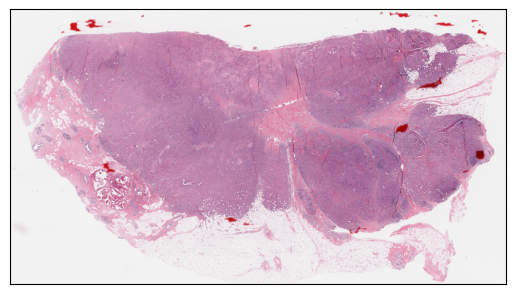

In [229]:
import openslide
import matplotlib.pyplot as plt
from sympy import apart

# 打开SVS文件
slide = openslide.OpenSlide(slide_path)

# 获取缩略图
thumbnail = slide.get_thumbnail((10*max(coord[:,0])+70, -1))

fig, ax = plt.subplots()

# 使用matplotlib显示缩略图
ax.imshow(thumbnail)
# plt.axis('off')

# plt.scatter(x=coord[:,0]*10, y=coord[:,1]*10, s=5, alpha=0.5)
# # 设置x和y轴的最小刻度为0
plt.xlim(xmin=10, xmax=1130)
plt.ylim(ymin=80, ymax=700)

# 按照y轴翻转散点图
plt.gca().invert_yaxis()

ax.set_xticks([])
ax.set_yticks([])


plt.savefig(case + '.svg', format='svg', bbox_inches='tight', pad_inches=0)
plt.show()

# 关闭SVS文件
slide.close()

In [206]:
import pandas as pd

cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/stnet/23209_C1/cell_ratio.csv").columns)[1:]]
cell_names

['CD4-positive helper T cell',
 'CD4-positive, alpha-beta T cell',
 'CD8-positive, alpha-beta memory T cell',
 'IgA plasma cell',
 'IgG plasma cell',
 'T cell',
 'activated CD4-positive, alpha-beta T cell',
 'activated CD8-positive, alpha-beta T cell',
 'alternatively activated macrophage',
 'basal cell',
 'capillary endothelial cell',
 'class switched memory B cell',
 'classical monocyte',
 'conventional dendritic cell',
 'effector memory CD4-positive, alpha-beta T cell',
 'effector memory CD8-positive, alpha-beta T cell',
 'endothelial cell of artery',
 'endothelial cell of lymphatic vessel',
 'fibroblast',
 'gamma-delta T cell',
 'inflammatory macrophage',
 'luminal epithelial cell of mammary gland',
 'lymphocyte',
 'macrophage',
 'mammary gland epithelial cell',
 'mast cell',
 'mature NK T cell',
 'myeloid cell',
 'myeloid dendritic cell',
 'naive B cell',
 'natural killer cell',
 'neutrophil',
 'non-classical monocyte',
 'pericyte',
 'plasmacytoid dendritic cell',
 'regulatory T c

CD4-positive, alpha-beta T cell


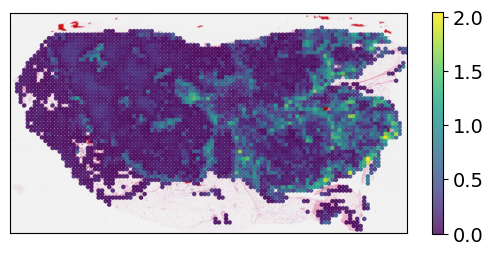

IgA plasma cell


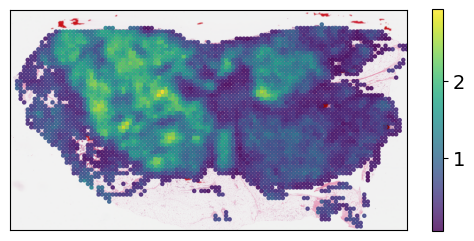

fibroblast


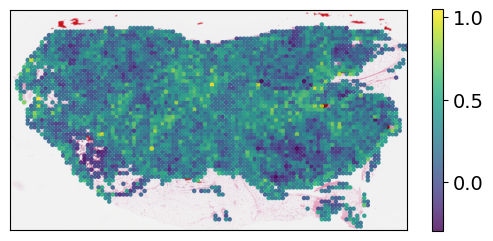

luminal epithelial cell of mammary gland


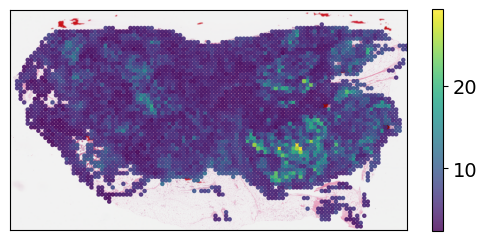

naive B cell


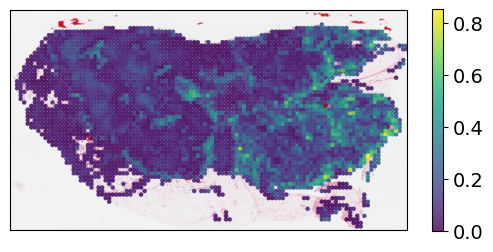

vascular associated smooth muscle cell


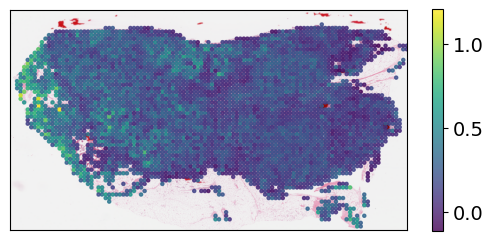

In [230]:
selected_cell_names = ['CD4-positive, alpha-beta T cell', 'fibroblast', 'IgA plasma cell', 'naive B cell', 'vascular associated smooth muscle cell', 'luminal epithelial cell of mammary gland']
for i in range(len(cell_names)):
    if cell_names[i] in selected_cell_names:
        print(cell_names[i])
        
        # 打开SVS文件
        slide = openslide.OpenSlide(slide_path)

        # 获取缩略图
        thumbnail = slide.get_thumbnail((10*max(coord[:,0])+70, -1))

        fig, ax = plt.subplots()
        
        # 使用matplotlib显示缩略图
        ax.imshow(thumbnail)
        # plt.axis('off')

        sc = ax.scatter(x=coord[:,0]*10, y=coord[:,1]*10, s=5, c=pred_abundance[:,i], alpha=0.8)

        # # 设置x和y轴的最小刻度为0
        plt.xlim(xmin=10, xmax=1130)
        plt.ylim(ymin=80, ymax=700)

        # 按照y轴翻转散点图
        plt.gca().invert_yaxis()

        # 关闭坐标轴
        # ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])

        # 添加color bar
        cbar = plt.colorbar(sc, ax=ax, shrink=0.6)

        # 设置 color bar 的刻度字体大小
        cbar.ax.tick_params(labelsize=14)  # 将字体大小设置为 1

        plt.savefig(case + '_' + cell_names[i] + '.svg', format='svg', bbox_inches='tight', pad_inches=0)
        
        plt.show()

        # 关闭SVS文件
        slide.close()